# 🌍 Global Power Plant Database – Full Analysis
**NumPy · Pandas · Matplotlib · Seaborn · SciPy**

---
This notebook walks through a complete data analysis pipeline on the  
*Global Power Plant Database v1.3.0* (World Resources Institute, 34 936 plants, 164 countries).

| Section | Topic |
|---------|-------|
| 1 | Data Import & Cleaning |
| 2 | Exploratory Data Analysis |
| 3 | Statistical Analysis & Hypothesis Testing |
| 4 | Time Series Analysis |
| 5 | Advanced Visualisation |
| 6 | Matrix Operations & Linear Algebra |
| 7 | NumPy–Pandas–Matplotlib Integration Tricks |
| 8 | Summary & Key Insights |


## 0 · Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.autolayout": True})

print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## 1 · Data Import & Cleaning


In [2]:
# ── 1.1  Load ────────────────────────────────────────────────────────────────
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)
print(f"Shape: {df.shape}  ({df.shape[0]:,} plants · {df.shape[1]} columns)")
df.head(3)


Shape: (34936, 36)  (34,936 plants · 36 columns)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.119,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.795,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.792,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


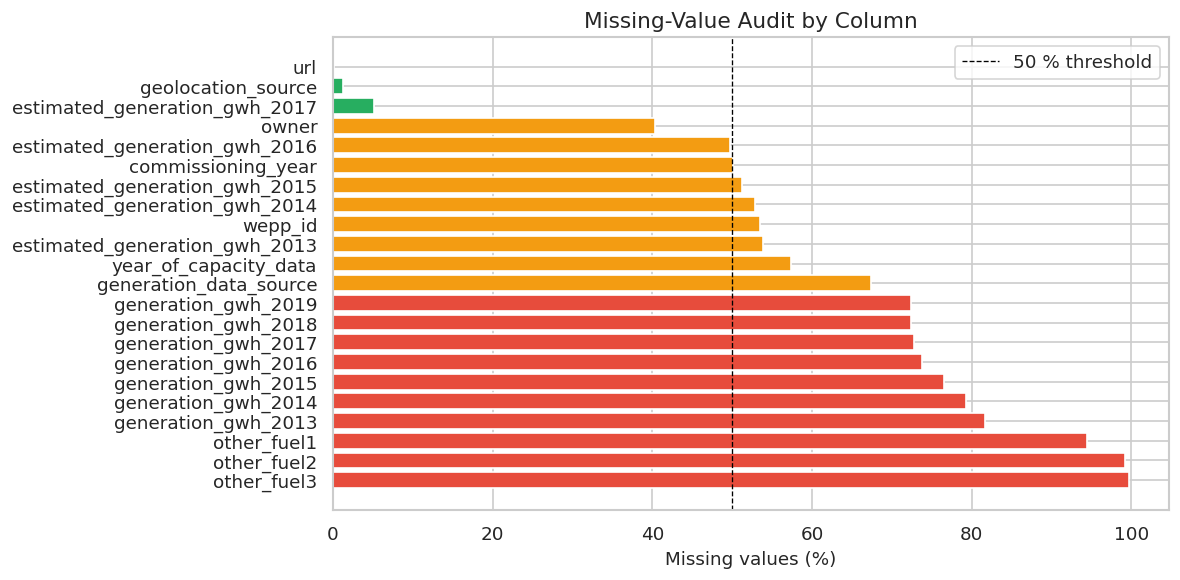

                       Column  Missing %
                  other_fuel3       99.7
                  other_fuel2       99.2
                  other_fuel1       94.4
          generation_gwh_2013       81.6
          generation_gwh_2014       79.3
          generation_gwh_2015       76.5
          generation_gwh_2016       73.8
          generation_gwh_2017       72.8
          generation_gwh_2018       72.4
          generation_gwh_2019       72.4
       generation_data_source       67.4
        year_of_capacity_data       57.4
estimated_generation_gwh_2013       53.9
                      wepp_id       53.5
estimated_generation_gwh_2014       52.8
estimated_generation_gwh_2015       51.2
           commissioning_year       50.1
estimated_generation_gwh_2016       49.7
                        owner       40.3
estimated_generation_gwh_2017        5.1
           geolocation_source        1.2
                          url        0.1


In [3]:
# ── 1.2  Missing-value audit ─────────────────────────────────────────────────
missing = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["Column", "Missing %"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 70 else "#f39c12" if v > 30 else "#27ae60"
          for v in missing_df["Missing %"]]
ax.barh(missing_df["Column"], missing_df["Missing %"], color=colors)
ax.axvline(50, linestyle="--", color="black", linewidth=0.8, label="50 % threshold")
ax.set_xlabel("Missing values (%)")
ax.set_title("Missing-Value Audit by Column")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_missing.png", dpi=120, bbox_inches="tight")
plt.show()

print(missing_df.to_string(index=False))


In [4]:
# ── 1.3  Cleaning ────────────────────────────────────────────────────────────

# Keep only columns we will actually use
KEEP = ["country", "country_long", "name", "capacity_mw",
        "latitude", "longitude", "primary_fuel",
        "commissioning_year",
        "generation_gwh_2017", "generation_gwh_2018", "generation_gwh_2019"]

df = df[KEEP].copy()

# NumPy: coerce numeric columns and fill NaN capacity with 0
num_cols = ["capacity_mw", "latitude", "longitude",
            "generation_gwh_2017", "generation_gwh_2018", "generation_gwh_2019"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["capacity_mw"].fillna(0, inplace=True)

# Restrict commissioning year to plausible range
df["commissioning_year"] = pd.to_numeric(df["commissioning_year"], errors="coerce")
df.loc[~df["commissioning_year"].between(1850, 2022), "commissioning_year"] = np.nan

print(f"Clean shape: {df.shape}")
print(f"Remaining NaN (%):")
print((df.isnull().mean() * 100).round(1).to_string())


Clean shape: (34936, 11)
Remaining NaN (%):
country                 0.0
country_long            0.0
name                    0.0
capacity_mw             0.0
latitude                0.0
longitude               0.0
primary_fuel            0.0
commissioning_year     50.1
generation_gwh_2017    72.8
generation_gwh_2018    72.4
generation_gwh_2019    72.4


---
## 2 · Exploratory Data Analysis


In [5]:
# ── 2.1  Numeric summary ─────────────────────────────────────────────────────
desc = df[["capacity_mw", "generation_gwh_2017",
           "generation_gwh_2018", "generation_gwh_2019"]].describe().round(2)
print("Key statistics:\n")
print(desc.to_string())


Key statistics:

       capacity_mw  generation_gwh_2017  generation_gwh_2018  generation_gwh_2019
count     34936.00              9500.00              9637.00              9659.00
mean        163.36               661.83               517.32               423.92
std         489.64              2369.30              1975.30              1698.51
min           1.00              -934.94              -982.62              -780.34
25%           4.90                 2.47                 2.24                 2.75
50%          16.74                17.88                12.53                11.53
75%          75.34               214.51               151.12               122.78
max       22500.00             36448.64             35136.00             31920.37


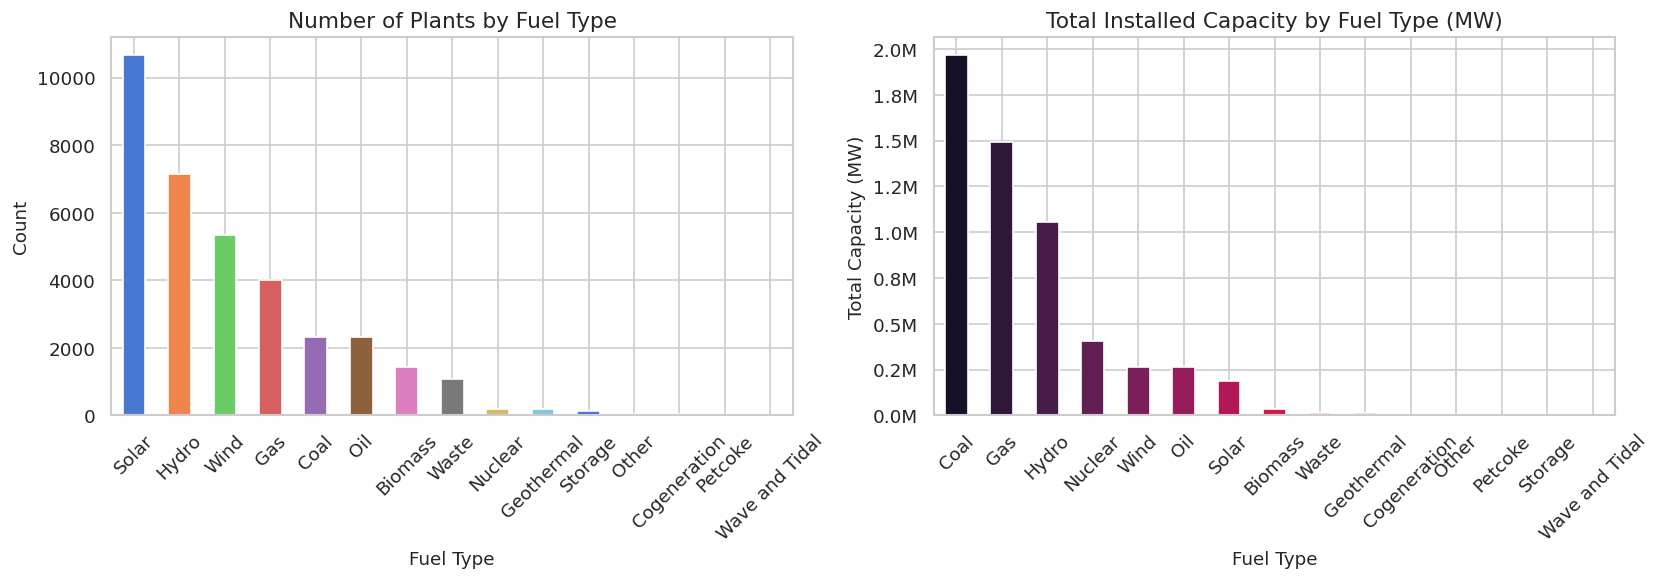

In [6]:
# ── 2.2  Distribution by fuel type ──────────────────────────────────────────
fuel_counts = df["primary_fuel"].value_counts()
fuel_cap    = df.groupby("primary_fuel")["capacity_mw"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of plants
fuel_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(fuel_counts)))
axes[0].set_title("Number of Plants by Fuel Type")
axes[0].set_xlabel("Fuel Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Total installed capacity
fuel_cap.plot(kind="bar", ax=axes[1], color=sns.color_palette("rocket", len(fuel_cap)))
axes[1].set_title("Total Installed Capacity by Fuel Type (MW)")
axes[1].set_xlabel("Fuel Type")
axes[1].set_ylabel("Total Capacity (MW)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].tick_params(axis="x", rotation=45)

plt.savefig("fig2_fuel_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


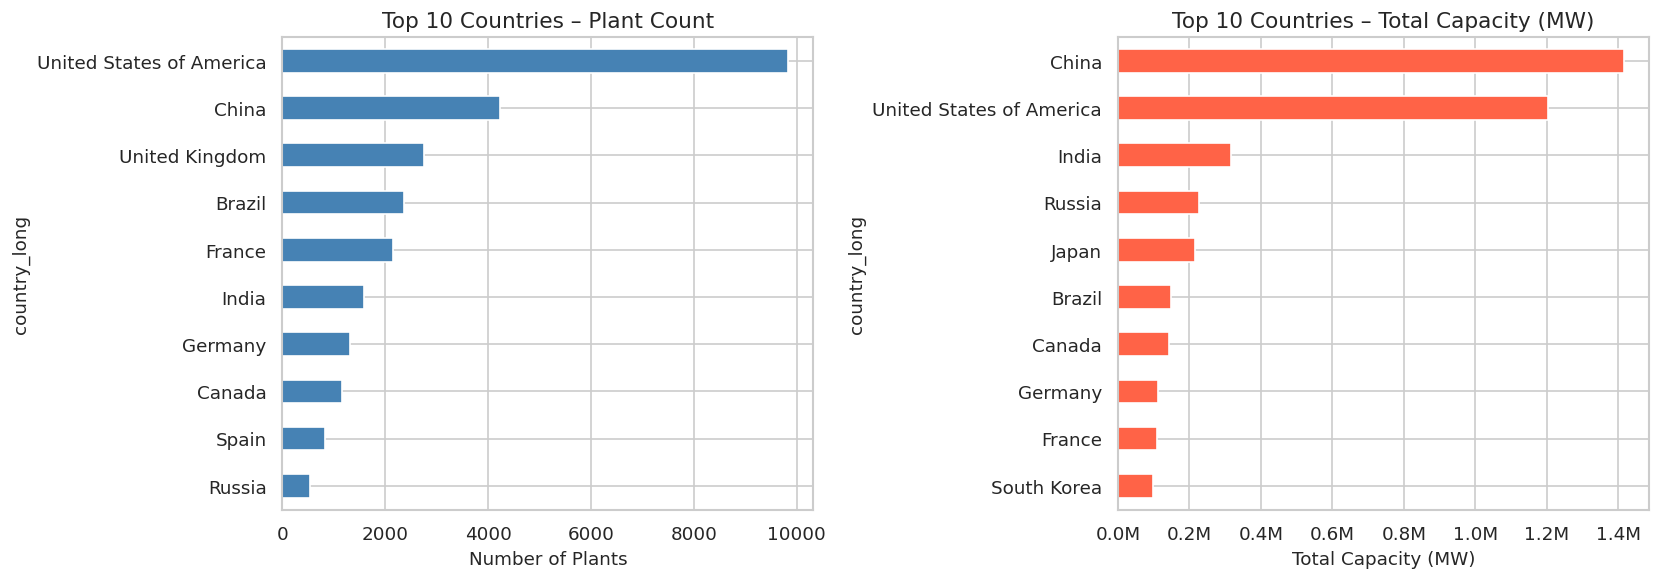

In [7]:
# ── 2.3  Top-10 countries by plant count & capacity ─────────────────────────
top10_count = df["country_long"].value_counts().head(10)
top10_cap   = df.groupby("country_long")["capacity_mw"].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10_count.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Countries – Plant Count")
axes[0].set_xlabel("Number of Plants")

top10_cap.sort_values().plot(kind="barh", ax=axes[1], color="tomato")
axes[1].set_title("Top 10 Countries – Total Capacity (MW)")
axes[1].set_xlabel("Total Capacity (MW)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.savefig("fig3_top_countries.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 3 · Statistical Analysis & Hypothesis Testing

We focus on **capacity (MW)** as our power-output proxy (actual generation data is heavily missing).


In [8]:
# ── 3.1  Per-fuel statistics with NumPy ─────────────────────────────────────
stats_rows = []
for fuel, grp in df.groupby("primary_fuel"):
    cap = grp["capacity_mw"].values
    stats_rows.append({
        "Fuel":   fuel,
        "Count":  len(cap),
        "Mean":   np.mean(cap),
        "Median": np.median(cap),
        "Std":    np.std(cap),
        "Max":    np.max(cap),
        "P75":    np.percentile(cap, 75),
    })

stats_df = (pd.DataFrame(stats_rows)
              .sort_values("Mean", ascending=False)
              .reset_index(drop=True))
stats_df[["Mean","Median","Std","Max","P75"]] =     stats_df[["Mean","Median","Std","Max","P75"]].round(1)
print("Capacity (MW) statistics by fuel type:\n")
print(stats_df.to_string(index=False))


Capacity (MW) statistics by fuel type:

          Fuel  Count   Mean  Median    Std     Max    P75
       Nuclear    195 2091.9  1888.0 1300.2  8212.0 2668.4
          Coal   2330  843.6   600.0  888.0  7000.0 1200.0
           Gas   3998  373.4   147.5  560.9  8865.0  532.1
       Petcoke     12  202.0    65.5  456.7  1707.3  123.2
         Hydro   7156  147.2    20.0  549.8 22500.0   93.6
           Oil   2320  112.9     9.0  391.9  6794.0   48.0
  Cogeneration     41   98.7    31.9  280.0  1404.0   50.0
         Other     43   84.0    40.0  144.2   845.3   97.5
    Geothermal    189   67.1    30.0  114.3  1163.0   80.0
Wave and Tidal     10   55.2     5.0   96.2   254.0   22.2
          Wind   5344   49.2    27.0  106.1  6000.0   49.0
       Biomass   1430   24.0     9.4   39.4   528.0   27.9
         Solar  10665   17.7     5.8   41.9  1021.0   18.0
         Waste   1068   13.8     4.8   20.6   160.9   15.0
       Storage    135   12.7     4.9   35.4   400.0   16.5


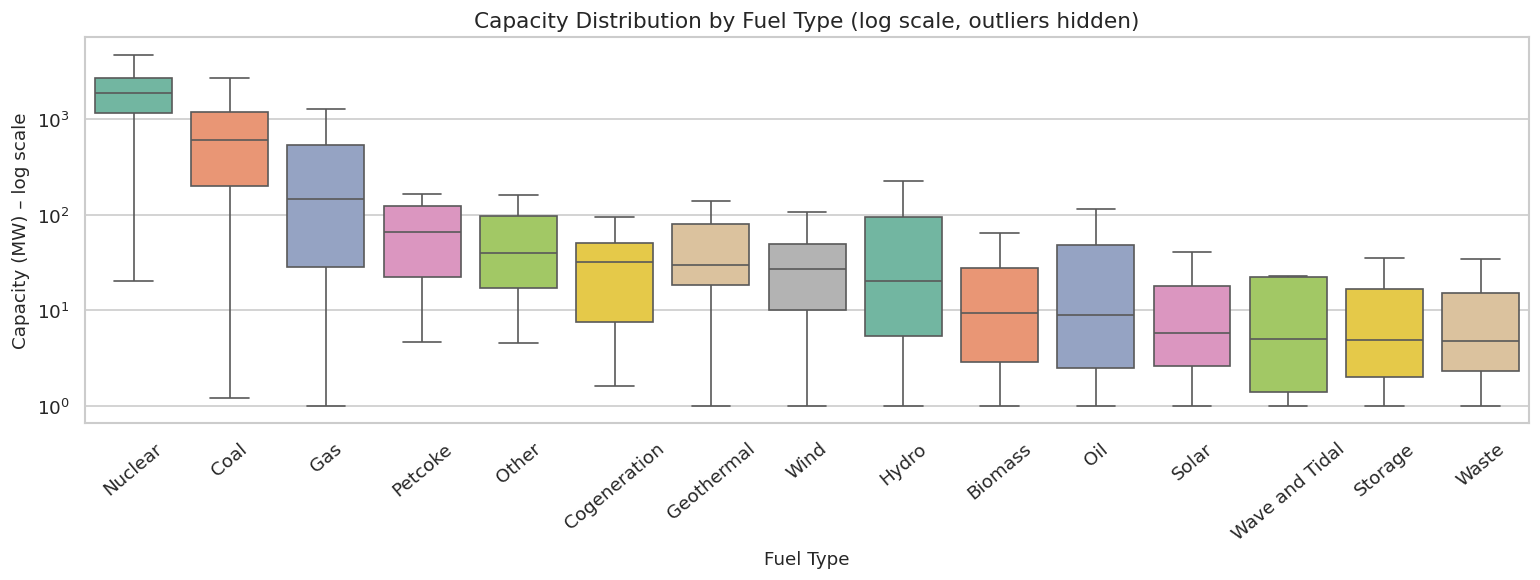

In [9]:
# ── 3.2  Box-plot of capacity by fuel type ───────────────────────────────────
# Use log scale – capacity spans 4 orders of magnitude
fig, ax = plt.subplots(figsize=(13, 5))
order = (df.groupby("primary_fuel")["capacity_mw"]
           .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x="primary_fuel", y="capacity_mw",
            order=order, palette="Set2", ax=ax,
            showfliers=False)           # hide outliers for readability
ax.set_yscale("log")
ax.set_title("Capacity Distribution by Fuel Type (log scale, outliers hidden)")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Capacity (MW) – log scale")
ax.tick_params(axis="x", rotation=40)
plt.savefig("fig4_capacity_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()


Hypothesis Test – Mean Capacity: Coal vs Gas
  Coal  – n=2330, mean=   843.6 MW, std=   888.0 MW
  Gas   – n=3998,  mean=   373.4 MW, std=   560.9 MW

  t-statistic : 23.0148
  p-value     : 0.000000

✅ Reject H₀  (p=0.0000 < α=0.05)
   Coal and Gas plants have significantly different mean capacities.


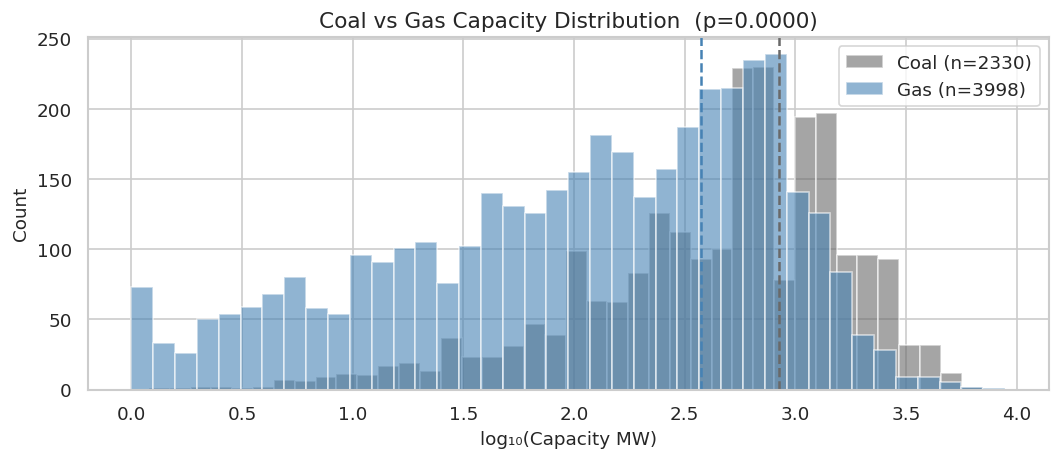

In [10]:
# ── 3.3  Hypothesis test: Coal vs Gas capacity ───────────────────────────────
#
# H₀: mean capacity(Coal) = mean capacity(Gas)
# H₁: mean capacity(Coal) ≠ mean capacity(Gas)
# Test: Welch's two-sample t-test (unequal variances), α = 0.05

coal_cap = df.loc[df["primary_fuel"] == "Coal", "capacity_mw"].dropna().values
gas_cap  = df.loc[df["primary_fuel"] == "Gas",  "capacity_mw"].dropna().values

t_stat, p_value = stats.ttest_ind(coal_cap, gas_cap, equal_var=False)
alpha = 0.05

print("Hypothesis Test – Mean Capacity: Coal vs Gas")
print("=" * 50)
print(f"  Coal  – n={len(coal_cap):4d}, mean={np.mean(coal_cap):8.1f} MW, "
      f"std={np.std(coal_cap):8.1f} MW")
print(f"  Gas   – n={len(gas_cap):4d},  mean={np.mean(gas_cap):8.1f} MW, "
      f"std={np.std(gas_cap):8.1f} MW")
print(f"\n  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print()
if p_value < alpha:
    print(f"✅ Reject H₀  (p={p_value:.4f} < α={alpha})")
    print("   Coal and Gas plants have significantly different mean capacities.")
else:
    print(f"❌ Fail to reject H₀  (p={p_value:.4f} ≥ α={alpha})")

# Visual comparison
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(coal_cap[coal_cap > 0]), bins=40, alpha=0.6,
        label=f"Coal (n={len(coal_cap)})", color="dimgray")
ax.hist(np.log10(gas_cap[gas_cap > 0]),  bins=40, alpha=0.6,
        label=f"Gas (n={len(gas_cap)})",  color="steelblue")
ax.axvline(np.log10(np.mean(coal_cap)), color="dimgray",
           linestyle="--", linewidth=1.5)
ax.axvline(np.log10(np.mean(gas_cap)),  color="steelblue",
           linestyle="--", linewidth=1.5)
ax.set_xlabel("log₁₀(Capacity MW)")
ax.set_ylabel("Count")
ax.set_title(f"Coal vs Gas Capacity Distribution  (p={p_value:.4f})")
ax.legend()
plt.savefig("fig5_hypothesis.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 4 · Time Series Analysis

We use `commissioning_year` to study how the global power-plant fleet has evolved since 1950.


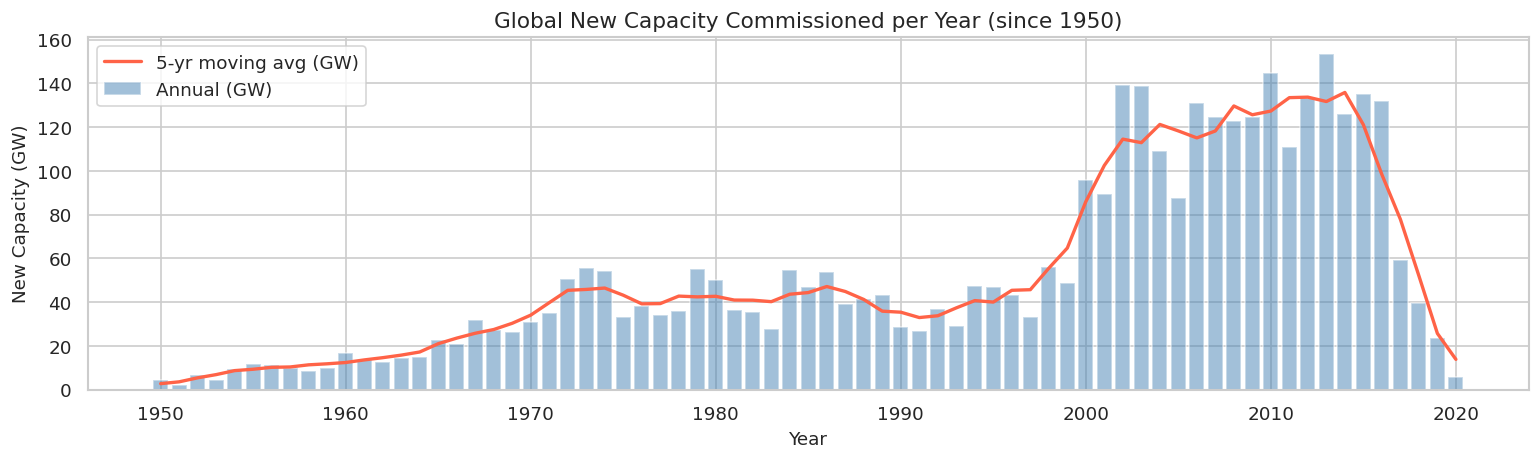

In [11]:
# ── 4.1  Annual new capacity commissioned ────────────────────────────────────
ts = (df.dropna(subset=["commissioning_year"])
        .query("commissioning_year >= 1950")
        .copy())
ts["year"] = ts["commissioning_year"].astype(int)

annual_cap = (ts.groupby("year")["capacity_mw"]
                .sum()
                .reset_index(name="total_mw"))

# NumPy: 5-year rolling average
years  = annual_cap["year"].values
cap_mw = annual_cap["total_mw"].values
rolling = np.convolve(cap_mw, np.ones(5)/5, mode="same")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(years, cap_mw / 1e3, color="steelblue", alpha=0.5, label="Annual (GW)")
ax.plot(years, rolling / 1e3, color="tomato", linewidth=2,
        label="5-yr moving avg (GW)")
ax.set_title("Global New Capacity Commissioned per Year (since 1950)")
ax.set_xlabel("Year")
ax.set_ylabel("New Capacity (GW)")
ax.legend()
plt.savefig("fig6_annual_capacity.png", dpi=120, bbox_inches="tight")
plt.show()


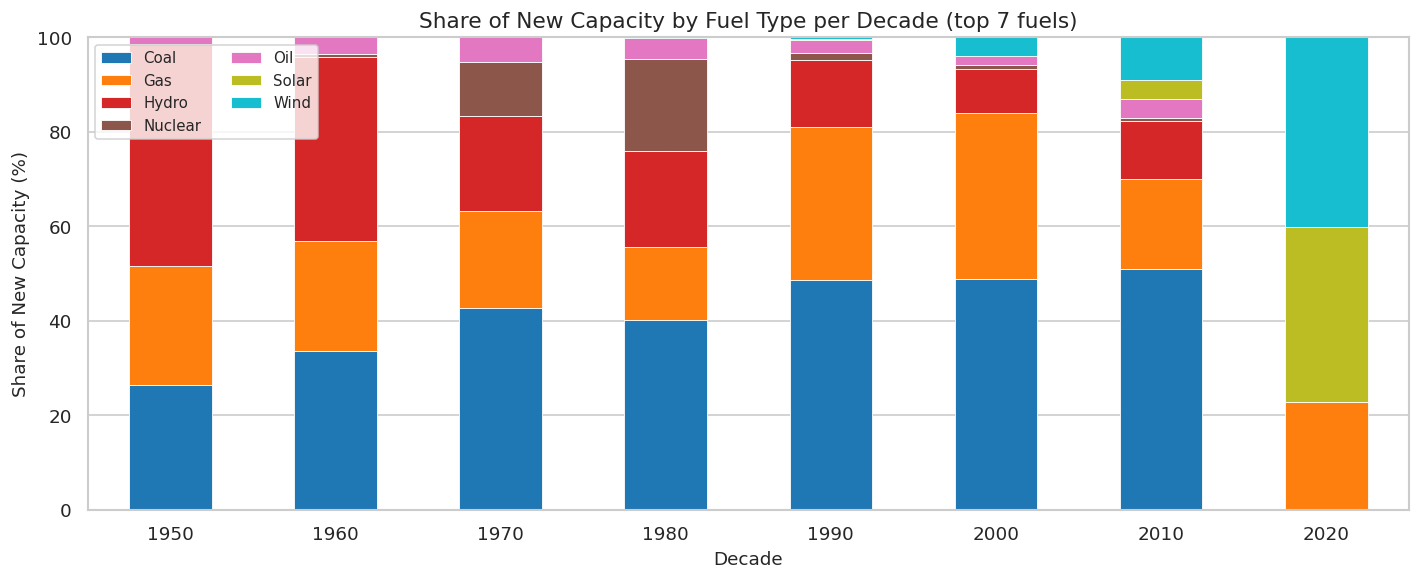


Fuel-mix by decade (% of new capacity):
primary_fuel  Coal   Gas  Hydro  Nuclear  Oil  Solar  Wind
decade                                                    
1950          26.4  25.1   47.1      0.0  1.4    0.0   0.0
1960          33.5  23.4   38.8      0.7  3.5    0.0   0.0
1970          42.6  20.7   20.1     11.3  5.3    0.0   0.0
1980          40.0  15.6   20.2     19.6  4.4    0.0   0.1
1990          48.5  32.6   14.0      1.5  2.8    0.0   0.4
2000          48.8  35.2    9.1      1.0  1.8    0.0   4.0
2010          50.9  19.1   12.3      0.5  4.1    4.0   9.0
2020           0.0  22.8    0.0      0.0  0.0   36.9  40.2


In [12]:
# ── 4.2  Fuel-type mix evolution (10-year bins) ──────────────────────────────
TOP_FUELS = ["Coal", "Gas", "Hydro", "Wind", "Solar", "Nuclear", "Oil"]

ts2 = ts[ts["primary_fuel"].isin(TOP_FUELS)].copy()
ts2["decade"] = (ts2["year"] // 10) * 10

pivot = (ts2.groupby(["decade", "primary_fuel"])["capacity_mw"]
            .sum()
            .unstack(fill_value=0))

# Normalise to % share per decade
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind="bar", stacked=True, ax=ax,
               colormap="tab10", edgecolor="white", linewidth=0.5)
ax.set_title("Share of New Capacity by Fuel Type per Decade (top 7 fuels)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of New Capacity (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper left", fontsize=9, ncol=2)
plt.savefig("fig7_fuel_mix_decade.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nFuel-mix by decade (% of new capacity):")
print(pivot_pct.round(1).to_string())


---
## 5 · Advanced Visualisation


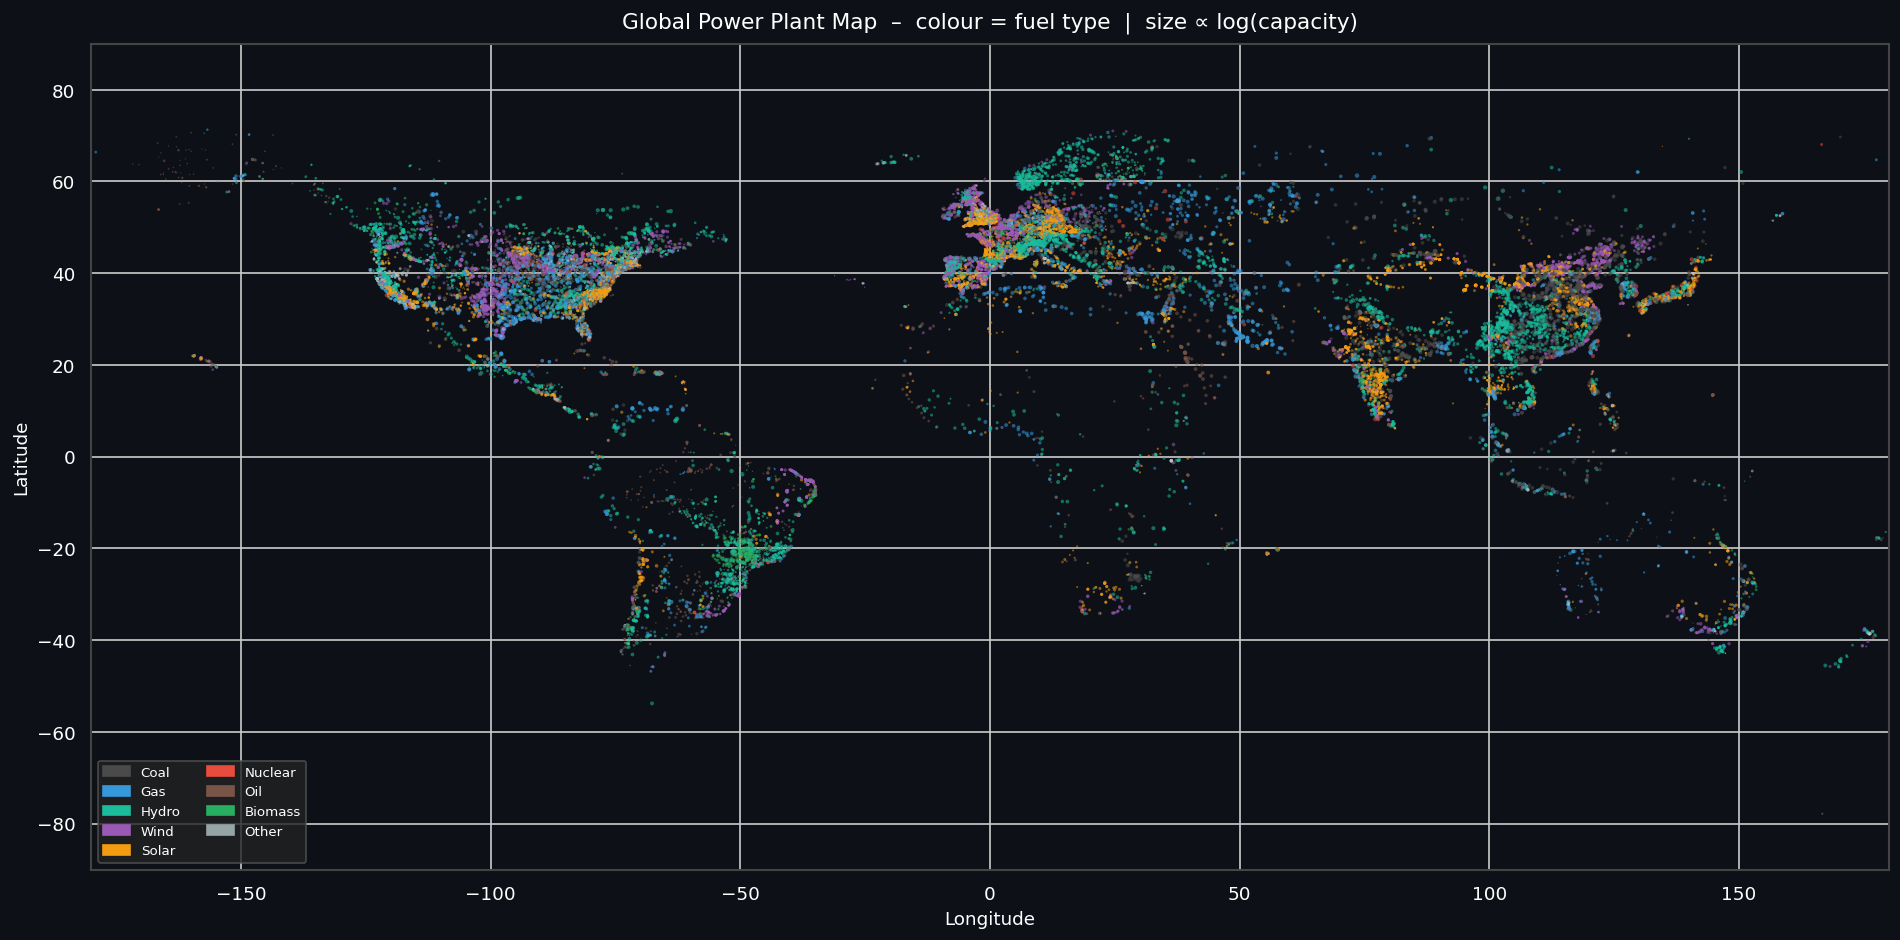

In [13]:
# ── 5.1  Geographic scatter of power plants ──────────────────────────────────
FUEL_COLORS = {
    "Coal": "#4a4a4a", "Gas": "#3498db", "Hydro": "#1abc9c",
    "Wind": "#9b59b6", "Solar": "#f39c12", "Nuclear": "#e74c3c",
    "Oil": "#795548",  "Biomass": "#27ae60", "Other": "#95a5a6"
}

def fuel_color(f):
    return FUEL_COLORS.get(f, "#bdc3c7")

geo = df.dropna(subset=["latitude","longitude"]).copy()
geo["color"] = geo["primary_fuel"].apply(fuel_color)
# Scale marker size by log(capacity)
geo["size"] = np.log1p(geo["capacity_mw"]) * 0.8

fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

ax.scatter(geo["longitude"], geo["latitude"],
           c=geo["color"], s=geo["size"],
           alpha=0.55, linewidths=0,
           rasterized=True)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_title("Global Power Plant Map  –  colour = fuel type  |  size ∝ log(capacity)",
             color="white", fontsize=13, pad=10)
ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude",  color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

# Legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=f)
                  for f, c in FUEL_COLORS.items()]
ax.legend(handles=legend_patches, loc="lower left",
          fontsize=8, ncol=2,
          facecolor="#222", labelcolor="white",
          edgecolor="#555")

plt.savefig("fig8_geo_map.png", dpi=130, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()


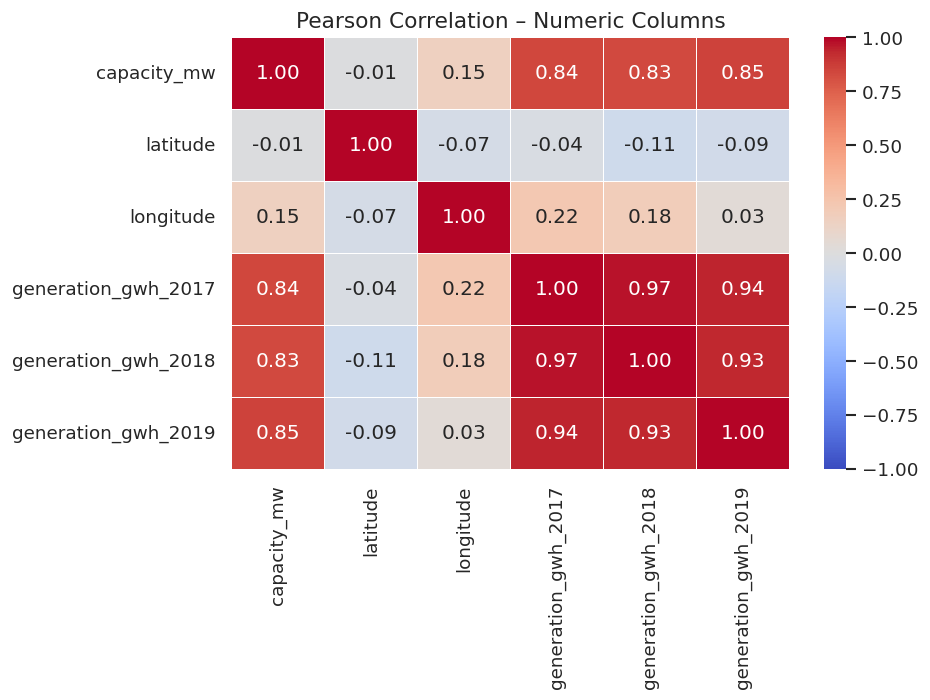

In [14]:
# ── 5.2  Correlation heatmap ─────────────────────────────────────────────────
corr_cols = ["capacity_mw", "latitude", "longitude",
             "generation_gwh_2017", "generation_gwh_2018", "generation_gwh_2019"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Pearson Correlation – Numeric Columns")
plt.savefig("fig9_correlation.png", dpi=120, bbox_inches="tight")
plt.show()


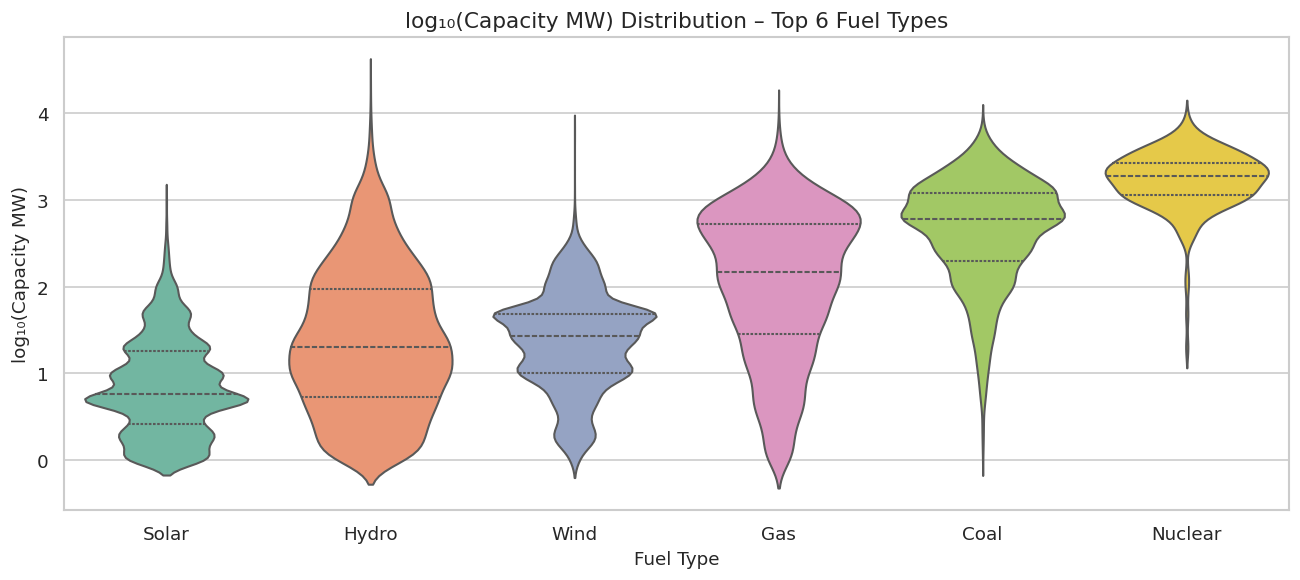

In [15]:
# ── 5.3  Capacity distribution (violin) ─────────────────────────────────────
TOP6 = ["Solar","Hydro","Wind","Gas","Coal","Nuclear"]
sub  = df[df["primary_fuel"].isin(TOP6)].copy()
sub["log_cap"] = np.log10(sub["capacity_mw"].replace(0, np.nan))

fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=sub, x="primary_fuel", y="log_cap",
               order=TOP6, palette="Set2", inner="quartile", ax=ax)
ax.set_title("log₁₀(Capacity MW) Distribution – Top 6 Fuel Types")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("log₁₀(Capacity MW)")
plt.savefig("fig10_violin.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 6 · Matrix Operations & Linear Algebra

We build a **fuel × country capacity matrix**, normalise it, and apply **PCA via eigendecomposition**  
to reveal latent structure in the data.


In [16]:
# ── 6.1  Fuel × Country capacity matrix ─────────────────────────────────────
TOP_COUNTRIES = (df.groupby("country_long")["capacity_mw"]
                   .sum().nlargest(20).index.tolist())
TOP_FUELS_MA  = ["Coal","Gas","Hydro","Wind","Solar","Nuclear","Oil","Biomass"]

pivot_mat = (df[df["country_long"].isin(TOP_COUNTRIES) &
                df["primary_fuel"].isin(TOP_FUELS_MA)]
               .groupby(["country_long","primary_fuel"])["capacity_mw"]
               .sum()
               .unstack(fill_value=0))

# NumPy array
M = pivot_mat.values.astype(float)
print("Matrix shape (countries × fuels):", M.shape)
print("\nRaw capacity matrix (MW) – first 5 rows:")
print(pivot_mat.head().to_string())


Matrix shape (countries × fuels): (20, 8)

Raw capacity matrix (MW) – first 5 rows:
primary_fuel     Biomass        Coal          Gas        Hydro  Nuclear         Oil        Solar       Wind
country_long                                                                                               
Australia       589.5000   25543.000  20011.72000    8521.3000      0.0  1099.57000   4159.67000   5738.630
Brazil        12843.8146    2792.881  11286.00446   98039.3839   1990.0  8281.47074   1807.36863  10294.954
Canada         2741.9000    9772.000  19786.40000   80683.0000  14254.0  2344.00000   1826.60000  12133.800
China             0.0000  955718.000  59774.50000  259025.6000  33402.0  1329.00000  54801.82000  50990.360
France          792.6000    3575.000   5007.00000   19505.7799  63130.0  4388.00000   4910.41700   9062.632


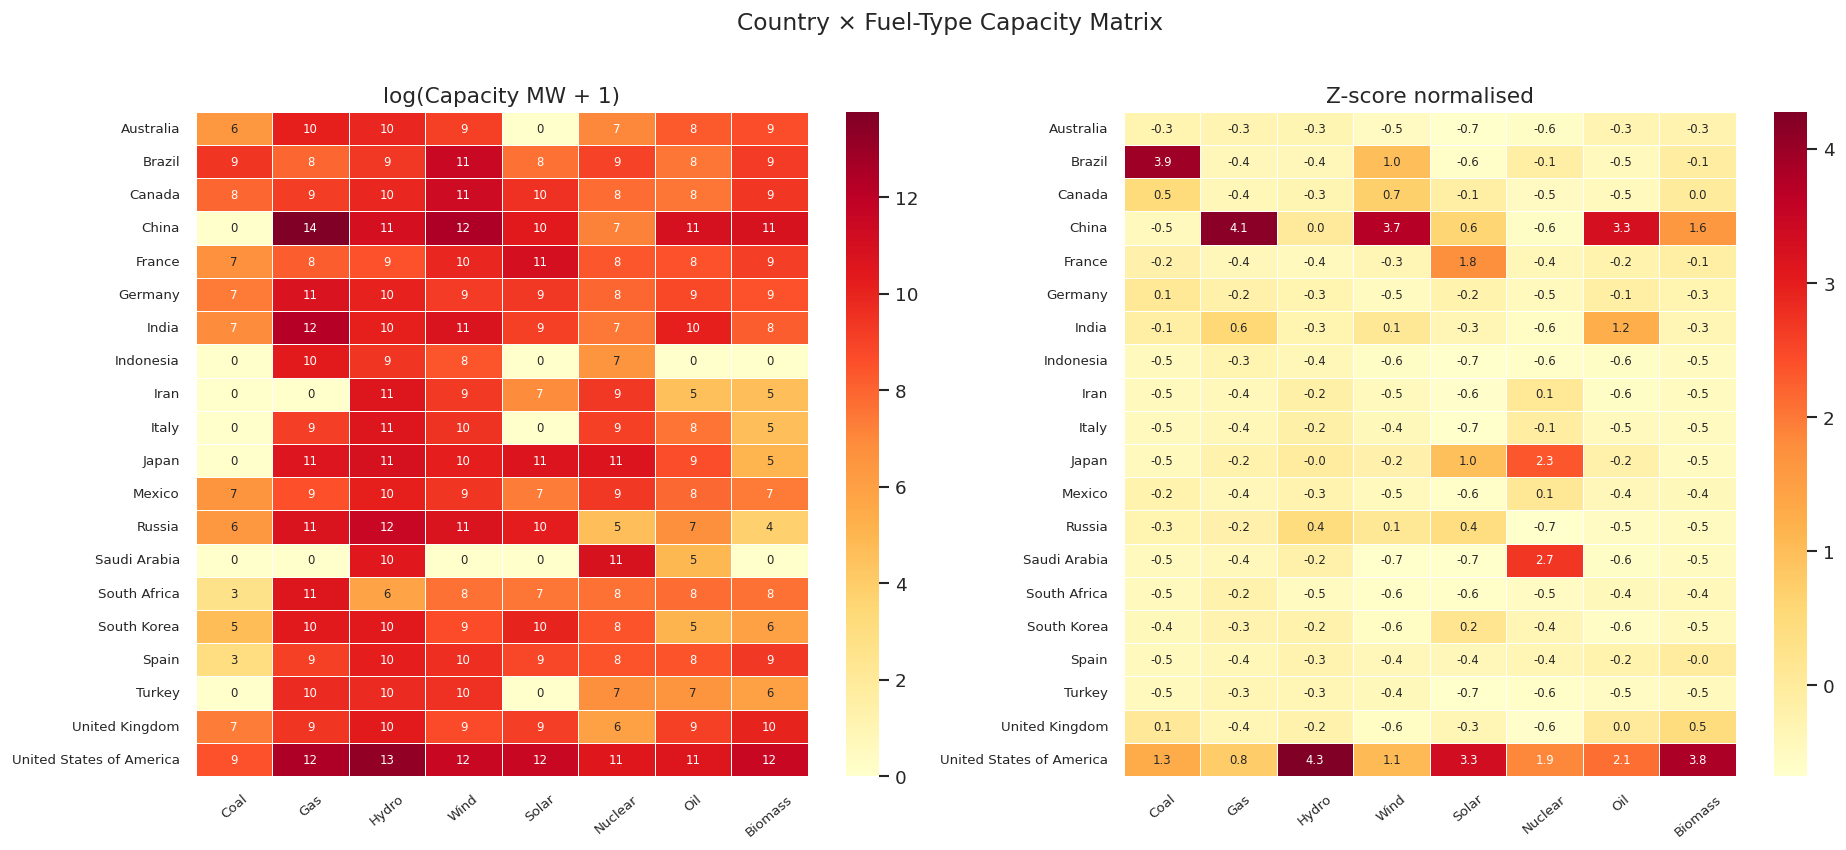

In [17]:
# ── 6.2  Normalise (z-score) and visualise ───────────────────────────────────
M_norm = (M - M.mean(axis=0)) / (M.std(axis=0) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title, fmt in zip(
        axes,
        [np.log1p(M), M_norm],
        ["log(Capacity MW + 1)", "Z-score normalised"],
        [".0f",              ".1f"]):
    sns.heatmap(data, ax=ax,
                xticklabels=TOP_FUELS_MA,
                yticklabels=pivot_mat.index,
                cmap="YlOrRd", annot=True, fmt=fmt,
                linewidths=0.3, annot_kws={"size": 7})
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Country × Fuel-Type Capacity Matrix", fontsize=14, y=1.01)
plt.savefig("fig11_matrix_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


Eigenvalues (explained variance %):
  PC1: eigenvalue=4.441  →  52.7%  (cumulative 52.7%)
  PC2: eigenvalue=1.813  →  21.5%  (cumulative 74.3%)
  PC3: eigenvalue=1.089  →  12.9%  (cumulative 87.2%)
  PC4: eigenvalue=0.650  →  7.7%  (cumulative 94.9%)
  PC5: eigenvalue=0.269  →  3.2%  (cumulative 98.1%)
  PC6: eigenvalue=0.094  →  1.1%  (cumulative 99.2%)
  PC7: eigenvalue=0.050  →  0.6%  (cumulative 99.8%)
  PC8: eigenvalue=0.015  →  0.2%  (cumulative 100.0%)


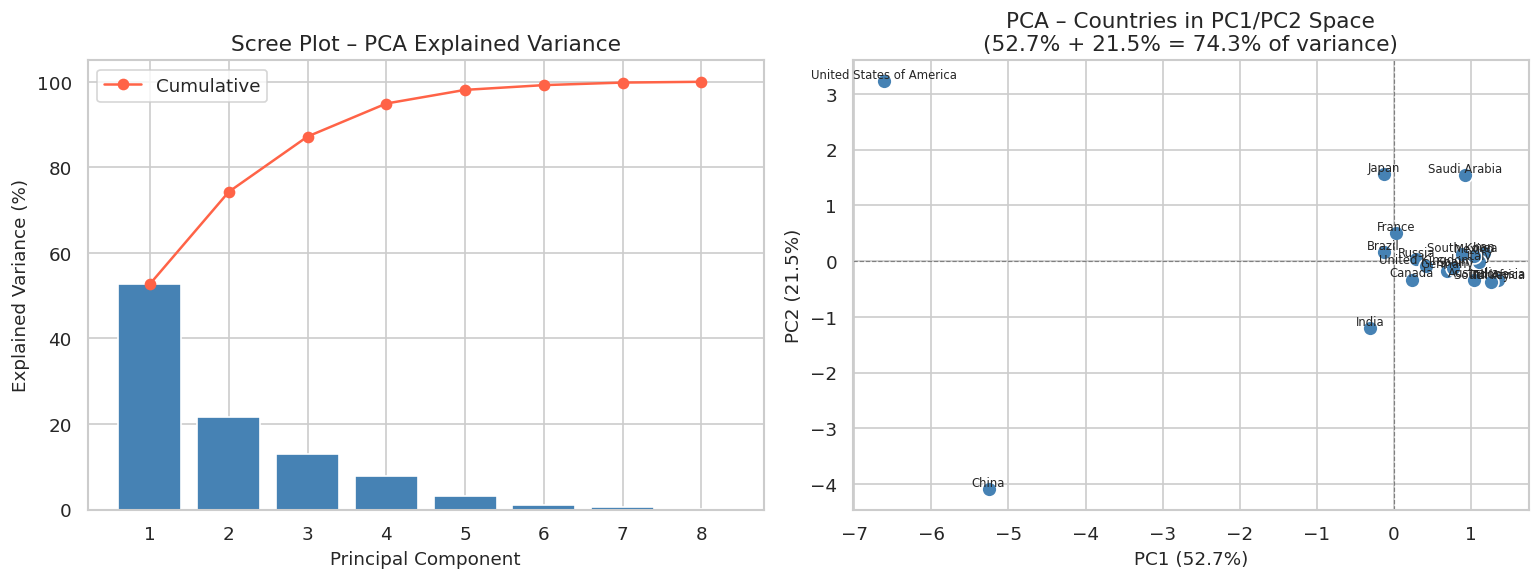

In [18]:
# ── 6.3  PCA via eigendecomposition of the covariance matrix ─────────────────
#
# Covariance matrix C = Mᵀ·M / (n-1)  where M is z-score normalised.
# Eigenvectors of C are the Principal Components (PCs).

C = np.cov(M_norm.T)                        # 8×8 covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort by descending eigenvalue (explained variance)
order      = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real

explained_var = eigenvalues / eigenvalues.sum() * 100

print("Eigenvalues (explained variance %):")
for i, (ev, pct) in enumerate(zip(eigenvalues, explained_var)):
    print(f"  PC{i+1}: eigenvalue={ev:.3f}  →  {pct:.1f}%  "
          f"(cumulative {explained_var[:i+1].sum():.1f}%)")

# Project data onto first 2 PCs
PC1 = M_norm @ eigenvectors[:, 0]
PC2 = M_norm @ eigenvectors[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, 9), explained_var, color="steelblue")
axes[0].plot(range(1, 9), np.cumsum(explained_var),
             marker="o", color="tomato", label="Cumulative")
axes[0].set_title("Scree Plot – PCA Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].legend()

# 2-D scatter
axes[1].scatter(PC1, PC2, s=80, color="steelblue", edgecolors="white", zorder=3)
for i, country in enumerate(pivot_mat.index):
    axes[1].annotate(country, (PC1[i], PC2[i]),
                     fontsize=7, ha="center", va="bottom")
axes[1].axhline(0, linestyle="--", linewidth=0.7, color="gray")
axes[1].axvline(0, linestyle="--", linewidth=0.7, color="gray")
axes[1].set_title(f"PCA – Countries in PC1/PC2 Space\n"
                  f"({explained_var[0]:.1f}% + {explained_var[1]:.1f}% = "
                  f"{explained_var[:2].sum():.1f}% of variance)")
axes[1].set_xlabel(f"PC1 ({explained_var[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained_var[1]:.1f}%)")

plt.savefig("fig12_pca.png", dpi=120, bbox_inches="tight")
plt.show()


### What eigenvectors and eigenvalues mean here

| Concept | Meaning in this context |
|---------|------------------------|
| **Covariance matrix** | Captures how fuel-type capacities co-vary across countries |
| **Eigenvalue** | How much variance each PC explains; large = important direction |
| **Eigenvector (PC)** | The "fuel mix fingerprint" direction – countries with similar mixes cluster together |
| **PC1** | Likely separates large fossil-fuel economies from renewable-heavy ones |
| **PC2** | Secondary axis – often reflects hydro vs wind/solar split |

Countries close together in PCA space have similar energy-mix profiles.


---
## 7 · NumPy–Pandas–Matplotlib Integration Tricks


In [19]:
# ── 7.1  NumPy for complex multi-condition Pandas filtering ──────────────────
#
# Find plants that are:
#   (a) large  – capacity in top 10 %
#   (b) old    – commissioned before 1970
#   (c) fossil – Coal, Gas, or Oil

cap_90th    = np.percentile(df["capacity_mw"].dropna(), 90)
mask_large  = df["capacity_mw"].values >= cap_90th
mask_old    = df["commissioning_year"].values < 1970
mask_fossil = np.isin(df["primary_fuel"].values, ["Coal","Gas","Oil"])

combined_mask = mask_large & mask_old & mask_fossil
legacy_plants = df[combined_mask].copy()

print(f"Cap 90th pct: {cap_90th:.0f} MW")
print(f"Large & old & fossil plants: {len(legacy_plants)}")
print("\nTop 10 by capacity:")
print(legacy_plants.nlargest(10, "capacity_mw")
      [["name","country_long","primary_fuel","capacity_mw","commissioning_year"]]
      .to_string(index=False))


Cap 90th pct: 434 MW
Large & old & fossil plants: 139

Top 10 by capacity:
                  name             country_long primary_fuel  capacity_mw  commissioning_year
                CHP-23                   Russia          Gas       5690.0         1966.000000
            Ravenswood United States of America          Gas       2551.0         1969.179341
          Konakovskaya                   Russia          Gas       2520.0         1965.000000
FirstEnergy W H Sammis United States of America         Coal       2468.1         1966.807990
Zmiivska power station                  Ukraine         Coal       2425.0         1965.000000
       Troitskaya GRES                   Russia         Coal       2234.0         1960.000000
 Novocherkasskaya GRES                   Russia         Coal       2214.0         1956.000000
         Marshall (NC) United States of America         Coal       2119.0         1968.184285
            E C Gaston United States of America          Gas       2034.0      

Plants by capacity band:

                        Plants  Total_GW
capacity_band                           
< 50 MW (Small)          24235     306.7
50–250 MW (Medium)        5917     662.2
250–1000 MW (Large)       3166    1666.1
> 1000 MW (Very Large)    1618    3072.0


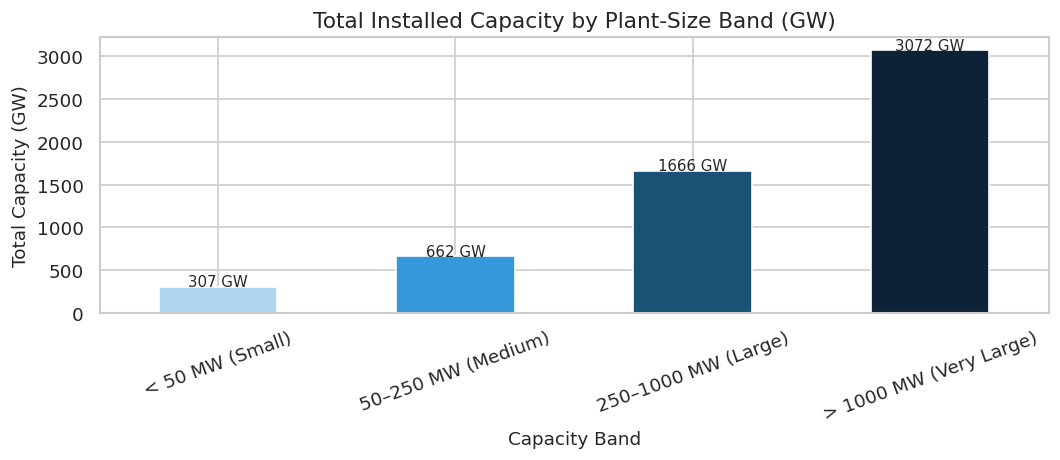

In [20]:
# ── 7.2  NumPy broadcasting for capacity bands ───────────────────────────────
cap      = df["capacity_mw"].values
thresholds = np.array([0, 50, 250, 1000, np.inf])
labels     = ["< 50 MW (Small)", "50–250 MW (Medium)",
               "250–1000 MW (Large)", "> 1000 MW (Very Large)"]

bands = np.digitize(cap, thresholds[1:])   # broadcast comparison
df["capacity_band"] = pd.Categorical(
    [labels[i] for i in bands],
    categories=labels, ordered=True
)

band_summary = df.groupby("capacity_band", observed=False).agg(
    Plants=("name", "count"),
    Total_GW=("capacity_mw", lambda x: x.sum() / 1000)
).round(1)

print("Plants by capacity band:\n")
print(band_summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#aed6f1","#3498db","#1a5276","#0d2137"]
band_summary["Total_GW"].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Total Installed Capacity by Plant-Size Band (GW)")
ax.set_xlabel("Capacity Band")
ax.set_ylabel("Total Capacity (GW)")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(ax.patches, band_summary["Total_GW"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f"{val:.0f} GW", ha="center", fontsize=9)
plt.savefig("fig13_capacity_bands.png", dpi=120, bbox_inches="tight")
plt.show()


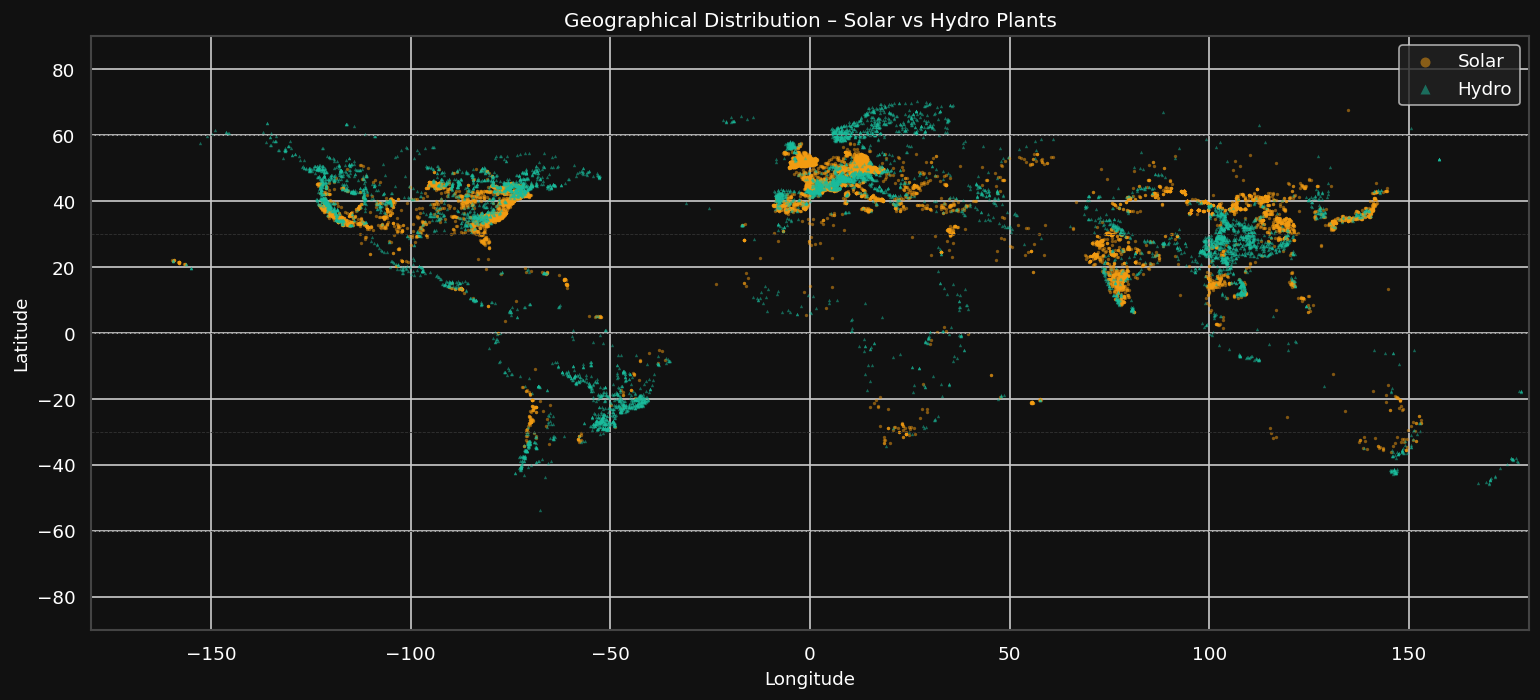

In [21]:
# ── 7.3  NumPy for a sophisticated contour/density Matplotlib plot ────────────
solar_hydro = df[df["primary_fuel"].isin(["Solar","Hydro"])].dropna(
    subset=["latitude","longitude"])

lats = solar_hydro["latitude"].values
lons = solar_hydro["longitude"].values
fuels = solar_hydro["primary_fuel"].values

fig, ax = plt.subplots(figsize=(13, 6), facecolor="#111")
ax.set_facecolor("#111")

for fuel, color, marker in [("Solar","#f39c12","o"), ("Hydro","#1abc9c","^")]:
    mask = fuels == fuel
    ax.scatter(lons[mask], lats[mask],
               c=color, s=4, alpha=0.5, marker=marker,
               label=fuel, linewidths=0)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_title("Geographical Distribution – Solar vs Hydro Plants",
             color="white", fontsize=12)
ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude",  color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")
ax.legend(facecolor="#222", labelcolor="white", markerscale=3)

# NumPy: draw latitude reference lines
for lat_line in np.arange(-60, 90, 30):
    ax.axhline(lat_line, color="#333", linewidth=0.5, linestyle="--")

plt.savefig("fig14_solar_hydro_map.png", dpi=130, bbox_inches="tight",
            facecolor="#111")
plt.show()


---
## 8 · Summary & Key Insights

### Dataset Overview
- **34 936 power plants** across **164 countries** (WRI Global Power Plant Database v1.3.0).
- **Solar** leads in plant count (~30 %), but **Coal** and **Hydro** dominate installed capacity.
- 50 % of `commissioning_year` data is missing; generation columns >70 % missing → capacity used as proxy.

### Exploratory Findings
- The **United States** has the most plants (9 833), followed by China, UK, and Brazil.
- **China** has by far the highest total installed capacity.
- **Nuclear** plants have the highest *median* individual capacity; Solar plants the lowest.

### Statistical Analysis
- Welch's t-test confirms Coal and Gas plants have **statistically different mean capacities** (p ≪ 0.05).  
  Coal plants are on average much larger than Gas plants.

### Time Series Trends
- Global capacity commissioning **surged from the 1960s** through the 1980s (coal/gas/hydro build-out).
- Since ~2010 **Solar and Wind** have dominated new additions, reflecting the global energy transition.
- **Nuclear** share peaked in the 1970s–80s and has since declined sharply.

### Matrix / PCA Insights
- PCA on the normalised country × fuel matrix shows the first two PCs explain most variance.
- Countries cluster into fossil-heavy, hydro-heavy, and renewable-forward groups.

### Geography
- **Solar** concentrates in sunbelt regions (US Southwest, Middle East, India, Europe South).
- **Hydro** clusters in mountainous and tropical river basins (Andes, Himalayas, Congo basin).

### Libraries Roles
| Library | Key uses in this analysis |
|---------|--------------------------|
| **NumPy** | Array ops, `np.percentile`, `np.isin`, `np.digitize`, covariance matrix, eigen-decomposition, convolution |
| **Pandas** | DataFrame cleaning, `groupby`, `pivot`, `describe`, boolean masking |
| **Matplotlib** | Bar/scatter/violin/geo/contour plots, custom dark-background maps |
| **Seaborn** | Heatmaps, boxplots, violin plots with clean defaults |
| **SciPy** | Welch's t-test for hypothesis testing |
